In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

import sys

Liste_features_simple = ["Sex",
                         "Age"	, # poly lineariser sur 0 1
                         "Time H-ICU"	,
                         "TIME SYMPTOMES-ICU"	,
                         "Time  DG-ICU", 
                         "Hem_mal"	,# a transformer par dic
                         "Dis_status HEM" ,# a transformer par dic
                         "HSCT_BMT",#dicoto allo auto
                         "GvHD"	, # ?
                         "Sys_dis",
                         "Solid_tumor"	,
                         "Organ_transpl"	,
                         #"Organ_transpl_spec"	,# peut se faire
                         "Drug_induced"	, # enlever les " "
                         "Chemotherapy"	,# enlever les " "
                         "Ibr_Flu_Met"	,
                         "Immuno_drugs"	,
                         "Tar_ther"	,
                         "Immunotherapy"	,
                         "Carttcells"	,
                         "Steroids_YN",
                         "Prophylaxis_pneumocystis",
                         "Prophylaxis_antifungal",
                         "Prophylaxis_bacterial"	,
                         "Prophylaxis_viral",
                         "Vaccins#Flu",
                         "Vaccins#COVID",
                         "Vaccins#Other",
                         "SOFA_score", # lineariser
                         "Resp_rate", # faire un score catégoriser avec intubation/Sp02
                         "SpO2",
                         "Temp", #a linéariser
                         "Neutrophils", #a catégoriser + clean
                         "Leukocytes",

]


# Charger le fichier Excel
df = pd.read_excel('D:/EFRAIM3 JD VANCE.xlsx')
# statistiques
features_etiology =[
                    'Etiology_Bacterial infection_Definitive diagnosis',
                    'Etiology_Viral infection_Definitive diagnosis',
                    'Etiology_Invasive pulmonary aspergillosis_Definitive diagnosis',
                    'Etiology_Pneumocystis jirovecii infection_Definitive diagnosis',
                    'Etiology_Mucorales_Definitive diagnosis',
                    'Etiology_Other fungal (specify below)_Definitive diagnosis',
                    'Etiology_Other infection (specify below)_Definitive diagnosis',
                    'Etiology_Cardiogenic pulmonary oedema_Definitive diagnosis',
                    'Etiology_Drug related_Definitive diagnosis',
                    'Etiology_Disease-related infiltrates_Definitive diagnosis',
                    'Etiology_Transfusion-related acute lung injury_Definitive diagnosis',
                    'Etiology_Other causes (specify below)_Definitive diagnosis',
                    'Etiology_Undetermined cause_Definitive diagnosis'
                    ]

df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')
df_col_utils = df[Liste_features_simple]
df_category = df[features_etiology]

L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","Resp_rate","Leukocytes"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features_simple
}
sys.modules.pop('feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)
# import importlib
# ft = importlib.import_module("utils.feature_transformer")
# sd = importlib.import_module("utils.stats_dataset")
# dq = importlib.import_module("utils.data_quality")
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features
from utils.data_quality import nettoyer_nan_par_colonne
df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean = nettoyer_lignes_vides(df_category)
df_col_utils = nettoyer_lignes_vides(df_col_utils)
df_features_clean = nettoyer_lignes_vides(df_features_clean)

🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 2164
Nombre de lignes totalement vides : 0
Nombre de lignes totalement vides : 0


Nombre de lignes contenant plus d’un '1' : 2383

Distribution des valeurs positives (1) par colonne (% des données totales) :
Bacterial infection                      38.22
Other causes (specify below)             27.29
Viral infection                          25.33
Cardiogenic pulmonary oedema             11.60
Disease-related infiltrates              10.67
Pneumocystis jirovecii infection          4.59
Invasive pulmonary aspergillosis          4.52
Other fungal (specify below)              3.64
Drug related                              3.64
Other infection (specify below)           3.25
Mucorales                                 1.21
Transfusion-related acute lung injury     0.32
dtype: float64


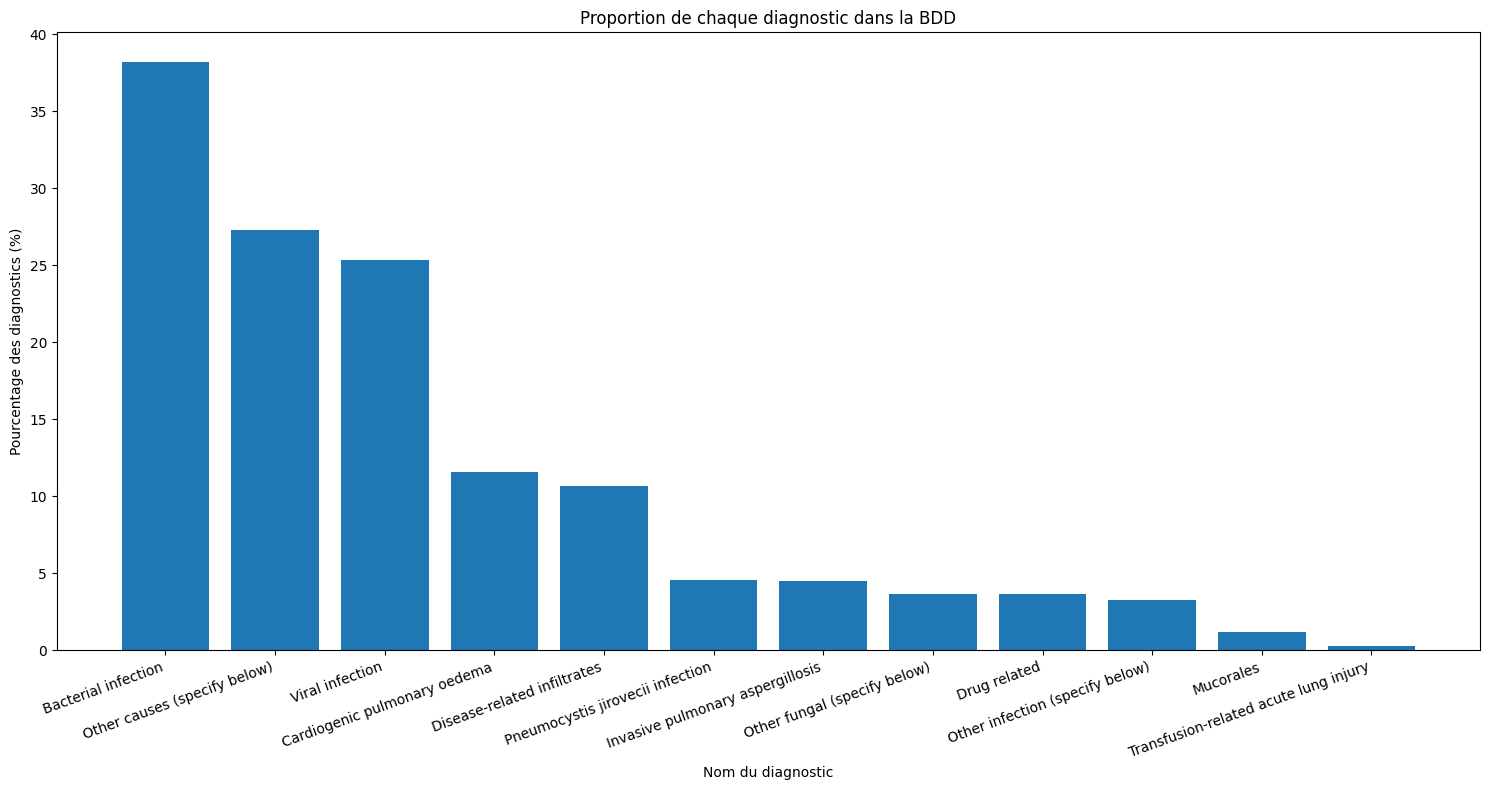

In [15]:
from utils.stats_dataset import analyser_variables_binaires,analyser_associations_binaires
distribution, nb_lignes = analyser_variables_binaires(df_cat_clean)

Nombre de lignes contenant plus d’un '1' : 2383

Associations les plus fréquentes (% des lignes totales) :
                                         Association  Fréquence  Pourcentage
0             (Bacterial infection, Viral infection)        645         8.90
1  (Bacterial infection, Other causes (specify be...        634         8.74
2    (Other causes (specify below), Viral infection)        366         5.05
3  (Bacterial infection, Disease-related infiltra...        251         3.46
4  (Bacterial infection, Cardiogenic pulmonary oe...        239         3.30


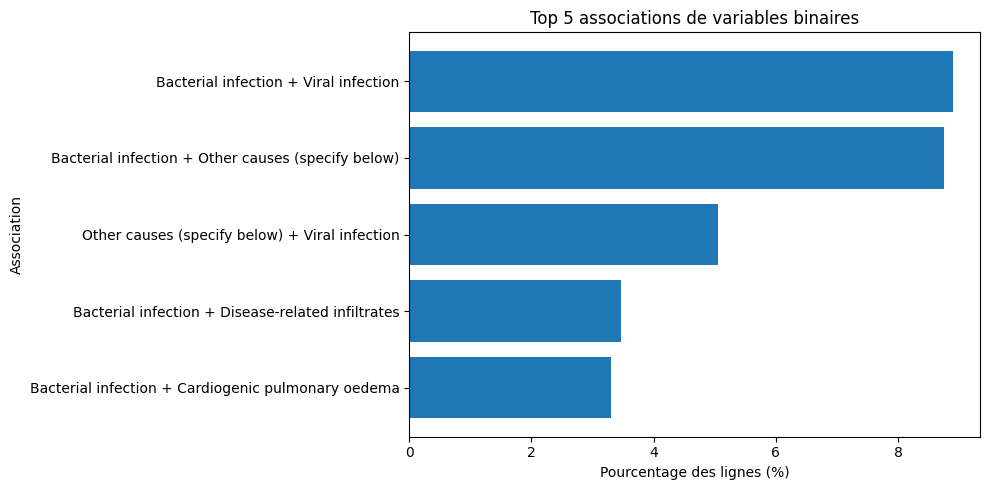

In [16]:
assoc_df, lignes_multi = analyser_associations_binaires(df_cat_clean, top_n=5)

Nombre de lignes totalement vides : 1627


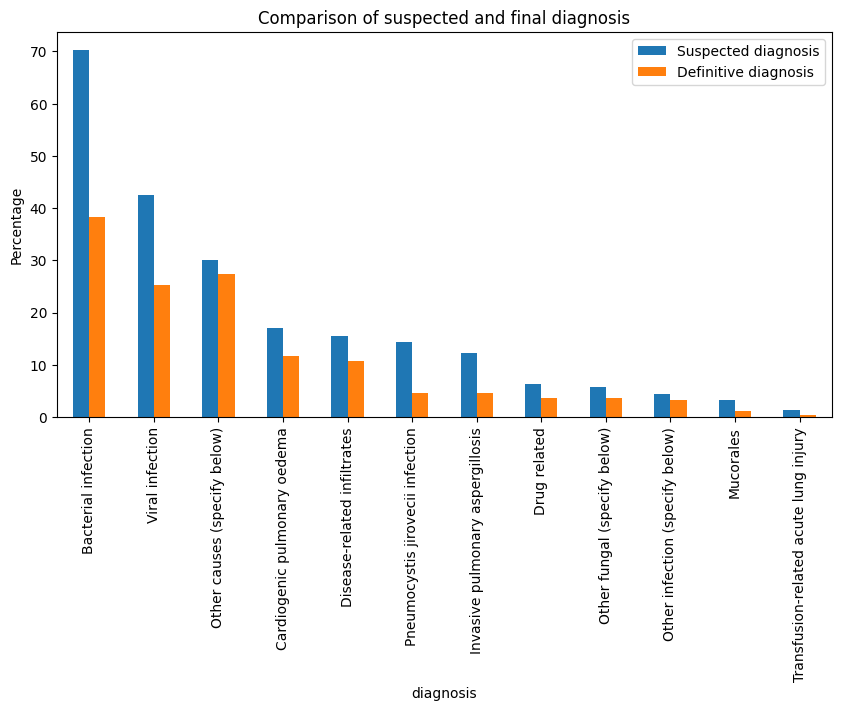

In [17]:

features_suspected = [col.replace("Definitive diagnosis", "Suspected at ICU adm") for col in features_etiology]
df_suspected = df[features_suspected]
df_suspected = nettoyer_colonnes(df_suspected)
df_suspected = nettoyer_lignes_vides(df_suspected)
distribution_suspected, nb_lignes = analyser_variables_binaires(df_suspected,print_results=False,visualisation=False)
distribution_diagnostique, nb_lignes = analyser_variables_binaires(df_cat_clean,print_results=False,visualisation=False)
import matplotlib.pyplot as plt
df_stats_suspected_vs_definitive = pd.concat([distribution_suspected, distribution_diagnostique], axis=1)
df_stats_suspected_vs_definitive.columns = ['Suspected diagnosis','Definitive diagnosis']

df_stats_suspected_vs_definitive.plot(kind='bar', figsize=(10, 5))
plt.xlabel('diagnosis')
plt.ylabel('Percentage')
plt.title('Comparison of suspected and final diagnosis')
plt.legend()
plt.show()


In [50]:
df_features_clean = df_features_clean.loc[df_cat_clean.index]
df_clean = pd.concat([df_features_clean,df_cat_clean], axis=1)

# Aucun prophilaxy et diagnostique

In [ ]:

cond_proph = df_clean["Prophylaxis_antifungal"] == 1

cond_fungal = (
    (df_clean["Mucorales"] == 1) |
    (df_clean["Other fungal (specify below)"] == 1) |
    (df_clean["Invasive pulmonary aspergillosis"] == 1)
)

ean = df_clean[cond_proph & cond_fungal]
# Nombre total
n_total_proph = cond_proph.sum()
n_total_fungal = cond_fungal.sum()
n_both = (cond_proph & cond_fungal).sum()

# Pourcentages
pct_proph = n_both / n_total_proph * 100 if n_total_proph > 0 else 0
pct_fungal = n_both / n_total_fungal * 100 if n_total_fungal > 0 else 0
print("=== Résultats ===")
print(f"Nombre total de patients : {len(df_clean)}")
print(f"Nombre total prophylaxie antifongique : {n_total_proph}")
print(f"Nombre total infection fongique      : {n_total_fungal}")
print(f"Nombre avec les deux conditions       : {n_both}")

print("\n=== Proportions ===")
print(f"→ Parmi les patients prophylaxés : {pct_proph:.2f}% ont une infection fongique.")
print(f"→ Parmi les patients infectés    : {pct_fungal:.2f}% avaient une prophylaxie.")


=== Résultats ===
Nombre total prophylaxie antifongique : 989
Nombre total infection fongique      : 626
Nombre avec les deux conditions       : 148

=== Proportions ===
→ Parmi les patients prophylaxés : 14.96% ont une infection fongique.
→ Parmi les patients infectés    : 23.64% avaient une prophylaxie.


In [51]:
df_clean

,Sex,Time H-ICU,TIME SYMPTOMES-ICU,Time DG-ICU,Sys_dis,Solid_tumor,Organ_transpl,Drug_induced,Chemotherapy,Ibr_Flu_Met,...,Invasive pulmonary aspergillosis,Pneumocystis jirovecii infection,Mucorales,Other fungal (specify below),Other infection (specify below),Cardiogenic pulmonary oedema,Drug related,Disease-related infiltrates,Transfusion-related acute lung injury,Other causes (specify below)
0,0.0,3.0,21.0,34.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,1.0,5667.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,19.0,19.0,91.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,2.0,9.0,12063.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,385.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9846,0.0,3.0,1.0,1601.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9848,1.0,6.0,6.0,2800.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9851,1.0,48.0,10.0,439.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9852,1.0,11.0,1.0,21.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:

cond_proph = df_clean["Prophylaxis_pneumocystis"] == 1

cond_fungal = (
    (df_clean['Pneumocystis jirovecii infection'] == 1 )
)

ean = df_clean[cond_proph & cond_fungal]

print("exemple des lignes avec prophylaxie et diagnostiques : ",ean.index)
# Nombre total
n_total_proph = cond_proph.sum()
n_total_fungal = cond_fungal.sum()
n_both = (cond_proph & cond_fungal).sum()

# Pourcentages
pct_proph = n_both / n_total_proph * 100 if n_total_proph > 0 else 0
pct_fungal = n_both / n_total_fungal * 100 if n_total_fungal > 0 else 0
print("=== Résultats ===")
print(f"Nombre total de patients : {len(df_clean)}")
print(f"Nombre total prophylaxie antipneucystis : {n_total_proph}")
print(f"Nombre total pneumocystose    : {n_total_fungal}")
print(f"Nombre avec les deux conditions       : {n_both}")

print("\n=== Proportions ===")
print(f"→ Parmi les patients prophylaxés : {pct_proph:.2f}% ont une pneumocystose.")
print(f"→ Parmi les patients infectés    : {pct_fungal:.2f}% avaient une prophylaxie.")


57 1436 333
Index([ 650,  762,  915,  937, 1108, 1119, 1411, 1880, 2127, 2157, 2317, 2328,
       2372, 2522, 2533, 2686, 2735, 2900, 2980, 2988, 2995, 2996, 3015, 3037,
       3072, 3092, 3141, 3149, 3291, 3387, 3622, 3788, 4075, 4171, 4555, 4668,
       4716, 4753, 4761, 4885, 4892, 5011, 5037, 5038, 5057, 5082, 5359, 5398,
       5494, 5747, 5796, 6270, 6836, 8481, 8598, 8979, 9392],
      dtype='int64')
=== Résultats ===
Nombre total de patients : 7251
Nombre total prophylaxie antipneucystis : 1436
Nombre total pneumocystose    : 333
Nombre avec les deux conditions       : 57

=== Proportions ===
→ Parmi les patients prophylaxés : 3.97% ont une pneumocystose.
→ Parmi les patients infectés    : 17.12% avaient une prophylaxie.


In [54]:
df_clean.dtypes

Sex                                      float64
Time H-ICU                               float64
TIME SYMPTOMES-ICU                       float64
Time  DG-ICU                             float64
Sys_dis                                  float64
Solid_tumor                              float64
Organ_transpl                            float64
Drug_induced                             float64
Chemotherapy                             float64
Ibr_Flu_Met                              float64
Immuno_drugs                             float64
Tar_ther                                 float64
Immunotherapy                            float64
Carttcells                               float64
Steroids_YN                              float64
Prophylaxis_pneumocystis                 float64
Prophylaxis_antifungal                   float64
Prophylaxis_bacterial                    float64
Prophylaxis_viral                        float64
Vaccins#Flu                              float64
Vaccins#COVID       